# DQN on Acrobot-v1

Loads [config.yaml](config.yaml) and trains the `QAgent` from `src/agents/q_agent.py`
on `Acrobot-v1`, built via `make_environment` in `src/environments/base_env.py`.

Acrobot has a `Box(6,)` observation space and a `Discrete(3)` action space, so DQN consumes
the raw continuous state and the native discrete actions — no discretisation or rescaling.

In [19]:
import sys, pathlib, yaml
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# notebook lives in experiments/dqn_acrobot/ -> repo root is parents[1]
SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from environments.base_env import make_environment
from agents.q_agent import QAgent
from training import dqn_training_loop

with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

req = cfg["experiment"]["device"]
device = req if (req != "mps" or torch.backends.mps.is_available()) else "cpu"
seed = cfg["experiment"]["seed"]
torch.manual_seed(seed); np.random.seed(seed)
print("device:", device); cfg

device: mps


{'experiment': {'name': 'dqn_acrobot', 'seed': 52, 'device': 'mps'},
 'environment': {'name': 'Acrobot-v1',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {}, 'state': {}}},
 'network': {'hidden_sizes': [128, 128]},
 'agent': {'replay_buffer_capacity': 10000,
  'batch_size': 128,
  'nn_learning_rate': 0.0003,
  'eps_start': 1.0,
  'eps_min': 0.05,
  'decay_rate': 0.99995,
  'discount_factor': 0.99,
  'TD_LR': 0.005,
  'buffer_util': 1},
 'training': {'no_episodes': 500, 'target_network_update_steps': 1}}

In [20]:
env_cfg = cfg["environment"]
env = make_environment(
    env_cfg["name"],
    render_mode=env_cfg["render_mode"],
    discrete_config=env_cfg["discrete_config"],   # None -> no discretisation
    normalise=env_cfg["normalise"],               # {action:{}, state:{}} -> no rescaling
)
obs_dim = env.observation_space.shape[0]          # 6
n_actions = env.action_space.n                    # 3
print("obs_dim:", obs_dim, "n_actions:", n_actions)

obs_dim: 6 n_actions: 3


In [21]:
class QNetwork(nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by QAgent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [22]:
a = cfg["agent"]
nn_extra_kwargs = {
    "in_dim": obs_dim,
    "out_dim": n_actions,
    "hidden_sizes": cfg["network"]["hidden_sizes"],
}
agent = QAgent(
    replay_buffer_capacity=a["replay_buffer_capacity"],
    q_network=QNetwork,
    batch_size=a["batch_size"],
    nn_learning_rate=a["nn_learning_rate"],
    nn_extra_kwargs=nn_extra_kwargs,
    env=env,
    eps_start=a["eps_start"],
    eps_min=a["eps_min"],
    decay_rate=a["decay_rate"],
    discount_factor=a["discount_factor"],
    device=device,
    TD_LR=a["TD_LR"],
    buffer_util=a["buffer_util"],
)

In [23]:
t = cfg["training"]
rewards = dqn_training_loop(
    agent, env,
    no_episodes=t["no_episodes"],
    target_network_update_steps=t["target_network_update_steps"],
    np_seed=seed,
)

  0%|          | 1/500 [00:01<12:38,  1.52s/it]

episode 0 is complete with reward-500.0
DEBUG INFO: replay_buffer_length500


  0%|          | 2/500 [00:02<10:23,  1.25s/it]

episode 1 is complete with reward-500.0
DEBUG INFO: replay_buffer_length1000


  1%|          | 3/500 [00:03<09:28,  1.14s/it]

...

episode 497 is complete with reward-83.0
DEBUG INFO: replay_buffer_length10000


100%|█████████▉| 499/500 [08:38<00:00,  1.19it/s]

episode 498 is complete with reward-123.0
DEBUG INFO: replay_buffer_length10000


100%|██████████| 500/500 [08:38<00:00,  1.04s/it]

episode 499 is complete with reward-78.0
DEBUG INFO: replay_buffer_length10000


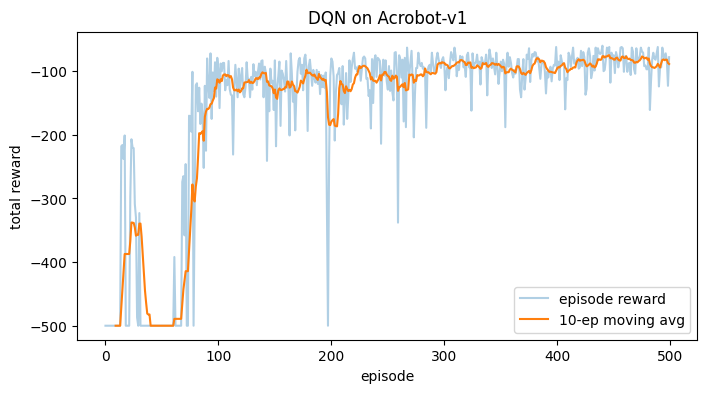

In [24]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on Acrobot-v1")
plt.legend(); plt.show()